In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier


In [2]:
DB_USER = "postgres"
DB_PASSWORD = "postgres"
DB_HOST = "localhost"
DB_PORT = 5433
DB_NAME = "efp_db"

connection_url = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_url)

# Quick check
with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM fact_sensor_readings"))
    print("Rows in fact_sensor_readings:", list(result)[0][0])


Rows in fact_sensor_readings: 998


In [3]:
query = """
SELECT
    machine_id,
    timestamp,
    temperature,
    vibration,
    pressure,
    error_code,
    operating_hours,
    failed_within_24h
FROM fact_sensor_readings
WHERE failed_within_24h IS NOT NULL;
"""

df = pd.read_sql(query, engine)
df.head()


,machine_id,timestamp,temperature,vibration,pressure,error_code,operating_hours,failed_within_24h
0,1,2025-11-24 11:09:11.512087+00:00,56.05,2.090,5.93,OK,3004.0,0
1,1,2025-11-24 11:39:11.512087+00:00,78.13,1.593,4.15,OK,3004.5,0
2,1,2025-11-24 12:09:11.512087+00:00,84.49,0.744,4.75,OK,3005.0,0
3,1,2025-11-24 12:39:11.512087+00:00,68.73,1.719,4.53,OK,3005.5,0
4,1,2025-11-24 13:09:11.512087+00:00,69.47,2.052,5.09,OK,3006.0,0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   machine_id         998 non-null    int64              
 1   timestamp          998 non-null    datetime64[ns, UTC]
 2   temperature        998 non-null    float64            
 3   vibration          998 non-null    float64            
 4   pressure           998 non-null    float64            
 5   error_code         998 non-null    object             
 6   operating_hours    998 non-null    float64            
 7   failed_within_24h  998 non-null    int64              
dtypes: datetime64[ns, UTC](1), float64(4), int64(2), object(1)
memory usage: 62.5+ KB


In [5]:
df["failed_within_24h"].value_counts(normalize=True) * 100


failed_within_24h
0    92.48497
1     7.51503
Name: proportion, dtype: float64

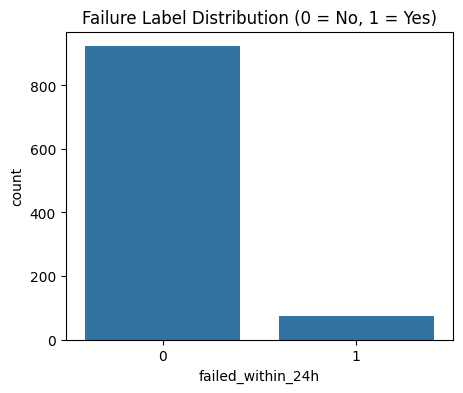

In [6]:
plt.figure(figsize=(5,4))
sns.countplot(x="failed_within_24h", data=df)
plt.title("Failure Label Distribution (0 = No, 1 = Yes)")
plt.show()


In [7]:
df[["temperature", "vibration", "pressure", "operating_hours"]].describe()


,temperature,vibration,pressure,operating_hours
count,998.000000,998.000000,998.000000,998.000000
mean,73.416994,1.816746,5.286974,2786.417836
std,12.953584,0.961976,1.269057,789.800061
min,36.630000,0.022000,1.830000,1848.100000
25%,64.237500,1.219250,4.410000,1922.450000
50%,71.985000,1.597000,5.200000,3046.100000
75%,80.977500,2.073500,5.960000,3113.575000
max,120.430000,5.335000,10.360000,4022.300000


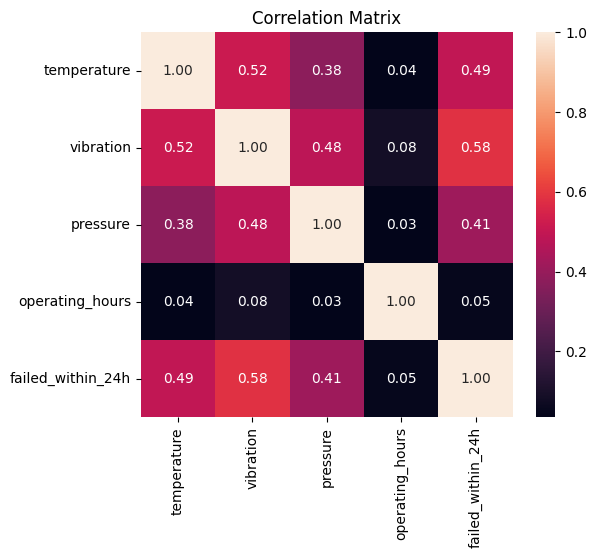

In [8]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df[["temperature", "vibration", "pressure", "operating_hours", "failed_within_24h"]].corr(),
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()


In [9]:
# Target
y = df["failed_within_24h"].astype(int)

# Features
feature_cols = [
    "machine_id",
    "temperature",
    "vibration",
    "pressure",
    "operating_hours",
    "error_code",
]

X = df[feature_cols].copy()


In [10]:
numeric_features = ["machine_id", "temperature", "vibration", "pressure", "operating_hours"]
categorical_features = ["error_code"]

numeric_features, categorical_features


(['machine_id', 'temperature', 'vibration', 'pressure', 'operating_hours'],
 ['error_code'])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((798, 6), (200, 6))

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("clf", rf_clf),
    ]
)


In [13]:
model.fit(X_train, y_train)
print("Model trained.")


Model trained.


In [14]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred))

try:
    auc = roc_auc_score(y_test, y_proba)
    print("ROC-AUC:", auc)
except Exception as e:
    print("Could not compute ROC-AUC:", e)


Accuracy: 0.94

Classification report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       185
           1       0.64      0.47      0.54        15

    accuracy                           0.94       200
   macro avg       0.80      0.72      0.75       200
weighted avg       0.93      0.94      0.94       200

ROC-AUC: 0.9736936936936937


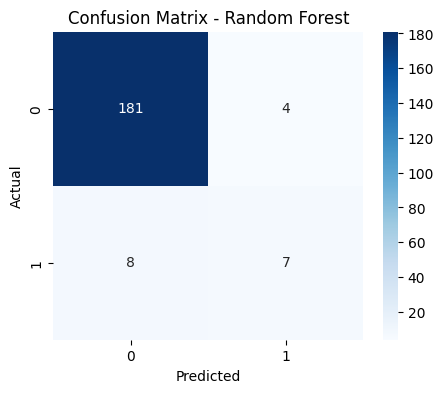

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


model.fit(X_train, y_train)
print("Model trained.")


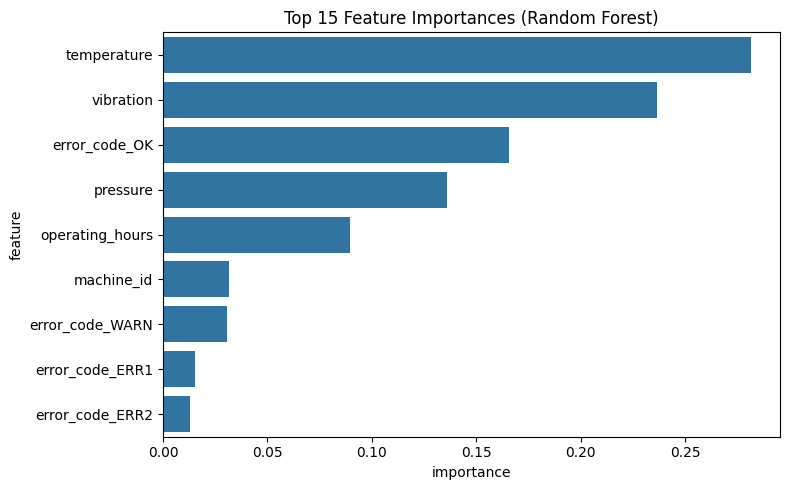

,feature,importance
1,temperature,0.281441
2,vibration,0.236696
7,error_code_OK,0.165556
3,pressure,0.135948
4,operating_hours,0.089577
0,machine_id,0.031465
8,error_code_WARN,0.030831
5,error_code_ERR1,0.015383
6,error_code_ERR2,0.013104


In [16]:
# Get fitted preprocessor and model
preproc_fitted = model.named_steps["preprocess"]
rf_fitted = model.named_steps["clf"]

# Get feature names after preprocessing
ohe = preproc_fitted.named_transformers_["cat"]
ohe_feature_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = np.concatenate([numeric_features, ohe_feature_names])

importances = rf_fitted.feature_importances_

feat_imp = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8,5))
sns.barplot(data=feat_imp, x="importance", y="feature")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

feat_imp
